# 04 – Model 2: DeBERTa-v3 NER Pipeline
Supervised token classification fine-tuned on the unified dataset.


In [9]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import glob
import json
from pathlib import Path
from src.utils.io import load_json, load_jsonl
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. How DeBERTa fine-tuning works — code walkthrough

In [10]:
# Model architecture: DeBERTa-v3-base + token classification head
# Pre-trained on 2.5B tokens, fine-tuned on our 37,661 training records

# Training configuration
training_config = {
    "model":            "microsoft/deberta-v3-base",
    "num_labels":       15,          # B/I × 7 entity types + O
    "max_length":       512,
    "batch_size":       16,
    "grad_accumulation": 2,          # effective batch = 32
    "learning_rate":    2e-5,
    "epochs":           10,
    "fp16":             True,        # mixed precision for RTX 3090
    "early_stopping":   3,           # patience
}

# BIO label schema
BIO_LABELS = (
    ["O"] +
    [f"{prefix}-{entity}"
     for entity in ["PERSON","EMAIL","PHONE","ADDRESS","URL","ID","USERNAME"]
     for prefix in ["B","I"]]
)

print("Model:", training_config["model"])
print(f"Labels ({len(BIO_LABELS)}):", BIO_LABELS)
print(f"\nTraining config:")
for k, v in training_config.items():
    print(f"  {k}: {v}")

Model: microsoft/deberta-v3-base
Labels (15): ['O', 'B-PERSON', 'I-PERSON', 'B-EMAIL', 'I-EMAIL', 'B-PHONE', 'I-PHONE', 'B-ADDRESS', 'I-ADDRESS', 'B-URL', 'I-URL', 'B-ID', 'I-ID', 'B-USERNAME', 'I-USERNAME']

Training config:
  model: microsoft/deberta-v3-base
  num_labels: 15
  max_length: 512
  batch_size: 16
  grad_accumulation: 2
  learning_rate: 2e-05
  epochs: 10
  fp16: True
  early_stopping: 3


## 2. Load pre-computed results (trained on BGU cluster)

In [11]:
# Results pre-computed on BGU cluster (RTX 3090, ~3.5 min inference)
results_path = Path('../outputs/results/ner_results.json')
results = load_json(results_path)
m = results['metrics']
print(f"DeBERTa — Precision: {m['precision']:.4f}  Recall: {m['recall']:.4f}  F1: {m['f1']:.4f}")

DeBERTa — Precision: 0.9895  Recall: 0.9910  F1: 0.9903


## 3. Training curves
*(reads Hugging Face trainer_state.json)*

Using: ../outputs/checkpoints/deberta\checkpoint-9416\trainer_state.json  (step 9416, epoch 8.0)


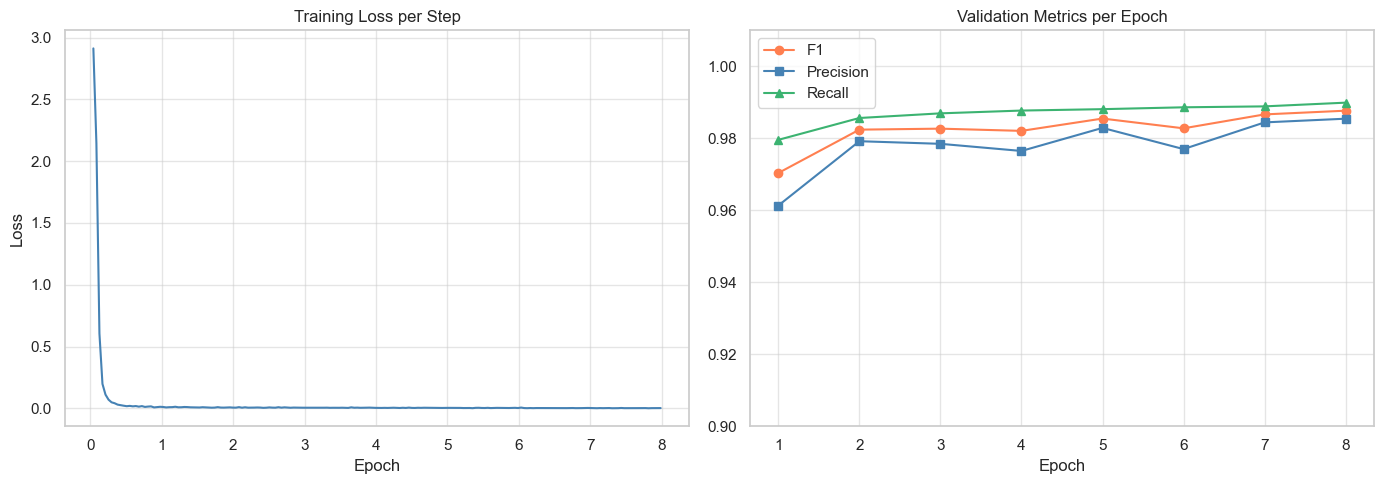


Best validation F1: 0.9877 at epoch 8.0


In [12]:
# Pick the trainer_state with the most steps (latest checkpoint)
state_files = glob.glob('../outputs/checkpoints/deberta/**/trainer_state.json', recursive=True)
state_files = sorted(state_files, key=lambda f: json.load(open(f)).get('global_step', 0), reverse=True)

if state_files:
    state = json.load(open(state_files[0]))
    print(f"Using: {state_files[0]}  (step {state['global_step']}, epoch {state['epoch']})")
    log = state.get('log_history', [])

    train_loss = [(e['epoch'], e['loss'])     for e in log if 'loss' in e and 'eval_loss' not in e]
    eval_rows  = [(e['epoch'], e['eval_f1'],
                   e['eval_precision'], e['eval_recall'])
                  for e in log if 'eval_f1' in e]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Training loss
    if train_loss:
        xs, ys = zip(*train_loss)
        axes[0].plot(xs, ys, color='steelblue', linewidth=1.5)
        axes[0].set_title('Training Loss per Step')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')

    # Validation F1, P, R per epoch
    if eval_rows:
        ep, f1, prec, rec = zip(*eval_rows)
        axes[1].plot(ep, f1,   color='coral',      marker='o', label='F1')
        axes[1].plot(ep, prec, color='steelblue',  marker='s', label='Precision')
        axes[1].plot(ep, rec,  color='mediumseagreen', marker='^', label='Recall')
        axes[1].set_title('Validation Metrics per Epoch')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylim(0.9, 1.01)
        axes[1].legend()

    plt.tight_layout()
    plt.savefig('../outputs/results/deberta_training_curves.png', dpi=150)
    plt.show()

    print(f"\nBest validation F1: {max(r[1] for r in eval_rows):.4f} at epoch {max(eval_rows, key=lambda r: r[1])[0]}")
else:
    print('No trainer_state.json found.')

## 4. Per-entity F1

,entity,precision,recall,f1,support
1,EMAIL,0.9935,0.9972,0.9954,1078
3,PERSON,0.9909,0.9970,0.9940,4373
6,USERNAME,0.9947,0.9742,0.9844,194
0,ADDRESS,0.9893,0.9756,0.9824,1514
5,URL,0.9655,0.9868,0.9760,227
4,PHONE,0.9817,0.9640,0.9727,222
2,ID,0.9462,1.0000,0.9724,88


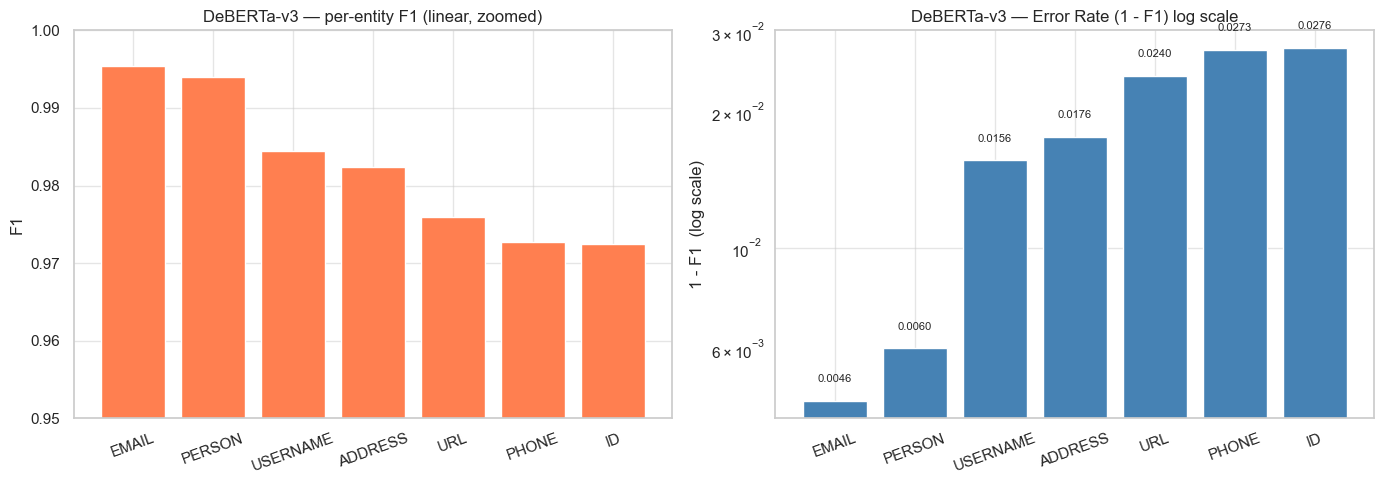

In [15]:
per = results['metrics'].get('per_entity', {})
df  = pd.DataFrame([{'entity': k, **v} for k, v in per.items()]).sort_values('f1', ascending=False)
display(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: linear scale (zoomed in)
axes[0].bar(df['entity'], df['f1'], color='coral', edgecolor='white')
axes[0].set_title('DeBERTa-v3 — per-entity F1 (linear, zoomed)')
axes[0].set_ylim(0.95, 1.0)
axes[0].set_ylabel('F1')
plt.setp(axes[0].get_xticklabels(), rotation=20)

# Right: error rate on log scale (1 - F1) to highlight differences
error = 1 - df['f1']
axes[1].bar(df['entity'], error, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('DeBERTa-v3 — Error Rate (1 - F1) log scale')
axes[1].set_ylabel('1 - F1  (log scale)')
plt.setp(axes[1].get_xticklabels(), rotation=20)
for i, (val, ent) in enumerate(zip(error, df['entity'])):
    axes[1].text(i, val * 1.1, f'{val:.4f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/results/deberta_per_entity_f1.png', dpi=150)
plt.show()

## 5. Qualitative sample

In [14]:
test_records = load_jsonl('../data/processed/test.jsonl')
preds = results['predictions']

for rec, pred in list(zip(test_records, preds))[:5]:
    true = rec['labels']
    text = ' '.join(rec['tokens'][:25])
    true_ents = [(t, l) for t, l in zip(rec['tokens'], true) if l != 'O']
    pred_ents = [(t, l) for t, l in zip(rec['tokens'], pred) if l != 'O']
    if true_ents or pred_ents:
        print(f'Text: {text} ...')
        print(f'  True: {true_ents[:5]}')
        print(f'  Pred: {pred_ents[:5]}')
        print()

Text: my friend rodriguez llc is interested in mindfulness - based therapy . can you recommend a podcast or youtube channel for them ? ...
  True: [('rodriguez', 'B-PERSON'), ('llc', 'I-PERSON')]
  Pred: [('rodriguez', 'B-PERSON'), ('llc', 'I-PERSON')]

Text: draft a document for sonia schmeler outlining safety protocols for handling confidential information and preventing data leaks . ...
  True: [('sonia', 'B-PERSON'), ('schmeler', 'I-PERSON')]
  Pred: [('sonia', 'B-PERSON'), ('schmeler', 'I-PERSON')]

Text: draft a list of key factors to consider when optimizing the logistics network for raul frami sr . ' s business . ...
  True: [('raul', 'B-PERSON'), ('frami', 'I-PERSON'), ('sr', 'I-PERSON'), ('.', 'I-PERSON')]
  Pred: [('raul', 'B-PERSON'), ('frami', 'I-PERSON'), ('sr', 'I-PERSON'), ('.', 'I-PERSON')]

Text: create a comparative analysis of the health care laws in massachusetts and massachusetts for jeffery kuhn , focusing on the key differences . ...
  True: [('massachusetts', '